In [ ]:
import random
import re
from collections import Counter
from functools import reduce
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Hugging Face dataset/training utilities.
from datasets import Dataset
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
BASE_DIR_DATA = Path('/kaggle/input/datasets/fasihhk/securiti-internship-data')
BASE_DIR_OUTPUT = Path('/kaggle/working')

train_path = BASE_DIR_DATA / 'data' / 'data.json'
test_path = BASE_DIR_DATA / 'data' / 'test_data.json'

df_intern = pd.read_json(train_path)
df_test = pd.read_json(test_path)

print('train rows:', len(df_intern))
print('test rows:', len(df_test))
df_intern.head(2)

train rows: 28516
test rows: 3650


,lang,ner_tags,sequence,tokens
0,en,"[O, O, O, O, B-PER, I-PER, O, O, O, O, B-PER, ...","Since then , only Terry Bradshaw in 147 games ...","[Since, then, ,, only, Terry, Bradshaw, in, 14..."
1,en,"[O, O, O, O, B-PER, I-PER, O, O, O, O, O, O, O...",He was portrayed by Anthony Perkins in the 196...,"[He, was, portrayed, by, Anthony, Perkins, in,..."


In [ ]:
def token_label_stats(df):
    # Flatten per-row tag lists and aggregate total token counts per label.
    return reduce(lambda a, x: a + Counter(x), df['ner_tags'], Counter())

print('Original train label distribution:')
print(token_label_stats(df_intern))

Original train label distribution:
Counter({'O': 639055, 'B-PER': 40264, 'I-PER': 29466})


#### Synthetic Email Strategy
1. Find person spans from `B-PER/I-PER`.
2. Build realistic emails from person names + domain distribution.
3. Mostly append context like `email <addr>` so PER supervision is retained.
4. Sometimes replace a person span with email so the model also learns substitution cases.

Default below: 75% append, 25% replace, and only augment a subset of examples with a PER span.

In [ ]:
# Common email domains used to generate synthetic addresses.
EMAIL_DOMAINS = [
    'gmail.com', 'outlook.com', 'yahoo.com', 'proton.me',
    'icloud.com', 'hotmail.com'
]

# Character substitutions to simulate noisy usernames.
LEET_MAP = {
    'a': ['a', '4', '@'],
    'e': ['e', '3'],
    'i': ['i', '1'],
    'o': ['o', '0'],
    's': ['s', '5', '$'],
    't': ['t', '7'],
    'g': ['g', '9'],
}


def find_person_spans(tags):
    # Extract contiguous B-PER/I-PER spans so augmentation can target real names.
    spans = []
    i = 0
    while i < len(tags):
        if tags[i] == 'B-PER':
            j = i + 1
            while j < len(tags) and tags[j] == 'I-PER':
                j += 1
            spans.append((i, j))
            i = j
        else:
            i += 1
    return spans


def _random_fragment(min_len=3, max_len=7):
    chars = 'abcdefghijklmnopqrstuvwxyz0123456789'
    size = random.randint(min_len, max_len)
    return ''.join(random.choice(chars) for _ in range(size))


def _add_local_noise(local):
    chars = list(local)

    # Character-level substitutions to mimic noisy, real-world handles.
    for idx, ch in enumerate(chars):
        lower = ch.lower()
        if lower in LEET_MAP and random.random() < 0.22:
            replacement = random.choice(LEET_MAP[lower])
            chars[idx] = replacement if ch.islower() else replacement.upper()

    noisy = ''.join(chars)

    # Random numeric suffixes are very common in real email handles.
    if random.random() < 0.55:
        noisy += str(random.randint(0, 9999))

    # Optional extra separators and fragments to diversify patterns.
    if random.random() < 0.25:
        noisy = noisy + random.choice(['_', '.', '-']) + _random_fragment(2, 4)

    if random.random() < 0.18:
        noisy = noisy + '+' + _random_fragment(2, 5)

    # Keep local part valid-ish and avoid awkward starts/ends.
    noisy = re.sub(r'[^a-zA-Z0-9._+\-]', '', noisy)
    noisy = re.sub(r'[._+\-]{2,}', '.', noisy)
    noisy = noisy.strip('._+-')

    if len(noisy) < 4:
        noisy = noisy + _random_fragment(3, 5)

    return noisy.lower()


def make_email_from_name(name_tokens):
    # Normalize source name tokens before composing synthetic emails.
    name_tokens = [re.sub(r'[^a-zA-Z0-9]', '', t.lower()) for t in name_tokens if t.strip()]
    name_tokens = [t for t in name_tokens if t]

    # Fallback path still creates realistic noisy IDs even when names are weak.
    if not name_tokens:
        local = _add_local_noise(_random_fragment(5, 9))
        return f'{local}@{random.choice(EMAIL_DOMAINS)}'

    first = name_tokens[0]
    last = name_tokens[-1]
    middle = name_tokens[1] if len(name_tokens) > 2 else ''

    # Pattern bank mixes conventional and noisy username styles.
    patterns = [
        f'{first}.{last}',
        f'{first}_{last}',
        f'{first}{last}',
        f'{first[0]}{last}',
        f'{first}{random.randint(10, 999)}',
        f'{first}.{middle}.{last}' if middle else f'{first}.{last}',
        f'{first}-{last}-{random.randint(1, 99)}',
        f'{first}{random.choice(["x", "z", "_", "."])}{_random_fragment(2, 5)}',
    ]

    local = _add_local_noise(random.choice(patterns))

    domain = random.choice(EMAIL_DOMAINS)
    if random.random() < 0.12:
        domain = random.choice(['mail', 'mx', 'm']) + '.' + domain

    return f'{local}@{domain}'

In [ ]:
def augment_row_with_email(tokens, tags, p_augment=0.35, p_append=0.75):
    tokens = list(tokens)
    tags = list(tags)

    # Only rows containing person spans are candidates for email injection.
    spans = find_person_spans(tags)
    if not spans or random.random() > p_augment:
        return tokens, tags

    # Pick one person span and synthesize an email from that local name context.
    span = random.choice(spans)
    s, e = span
    email_addr = make_email_from_name(tokens[s:e])
    if not email_addr:
        return tokens, tags

    if random.random() < p_append:
        # Append mode preserves original PER supervision and adds explicit email context.
        prefix = random.choice(['email', 'contact', 'reach'])
        sep = random.choice([':', 'at'])
        tokens_aug = tokens + [prefix, sep, email_addr]
        tags_aug = tags + ['O', 'O', 'B-EMAIL']
        return tokens_aug, tags_aug

    # Replace mode teaches the model that an entity slot may contain an email token instead.
    tokens_aug = tokens[:s] + [email_addr] + tokens[e:]
    tags_aug = tags[:s] + ['B-EMAIL'] + tags[e:]
    return tokens_aug, tags_aug

# Build one augmented version per training row.
aug_rows = []
for row in df_intern.itertuples(index=False):
    t_aug, y_aug = augment_row_with_email(row.tokens, row.ner_tags, p_augment=0.35, p_append=0.75)
    aug_rows.append({
        'lang': row.lang,
        'tokens': t_aug,
        'ner_tags': y_aug,
        'sequence': ' '.join(t_aug),
    })

df_v2 = pd.DataFrame(aug_rows)
print('Augmented train rows:', len(df_v2))
print('Augmented label distribution:')
print(token_label_stats(df_v2))
df_v2.head(2)

Augmented train rows: 28516
Augmented label distribution:
Counter({'O': 654127, 'B-PER': 37739, 'I-PER': 27701, 'B-EMAIL': 10061})


,lang,tokens,ner_tags,sequence
0,en,"[Since, then, ,, only, Terry, Bradshaw, in, 14...","[O, O, O, O, B-PER, I-PER, O, O, O, O, B-PER, ...","Since then , only Terry Bradshaw in 147 games ..."
1,en,"[He, was, portrayed, by, Anthony, Perkins, in,...","[O, O, O, O, B-PER, I-PER, O, O, O, O, O, O, O...",He was portrayed by Anthony Perkins in the 196...


In [6]:
out_aug = BASE_DIR_OUTPUT / 'data_with_synth_email.json'
df_v2.to_json(out_aug, orient='records', indent=2)
print('Saved augmented dataset to:', out_aug)

Saved augmented dataset to: /kaggle/working/data_with_synth_email.json


In [ ]:
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 96

# Label mapping used consistently during training and evaluation.
label_list = ['O', 'B-PER', 'I-PER', 'B-EMAIL', 'I-EMAIL']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

def normalize_tags(tags):
    # Defensive normalization for mixed string/int labels.
    out = []
    for t in tags:
        s = str(t).strip()
        if s.isdigit():
            s = id2label.get(int(s), 'O')
        out.append(s if s in label2id else 'O')
    return out

In [ ]:
# Train/validation split from augmented data.
train_df = df_v2.copy()
train_df['ner_tags'] = train_df['ner_tags'].apply(normalize_tags)

idx_train, idx_val = train_test_split(np.arange(len(train_df)), test_size=0.1, random_state=SEED, shuffle=True)
df_train = train_df.iloc[idx_train].reset_index(drop=True)
df_val = train_df.iloc[idx_val].reset_index(drop=True)

# Keep only token/tag columns for Hugging Face Dataset conversion.
ds_train = Dataset.from_pandas(df_train[['tokens', 'ner_tags']], preserve_index=False)
ds_val = Dataset.from_pandas(df_val[['tokens', 'ner_tags']], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(batch):
    # Tokenize with word-level alignment so labels follow split subwords correctly.
    tok = tokenizer(batch['tokens'], is_split_into_words=True, truncation=True, max_length=MAX_LENGTH)
    out_labels = []
    for i, tags in enumerate(batch['ner_tags']):
        word_ids = tok.word_ids(batch_index=i)
        prev = None
        ids = []
        for w in word_ids:
            if w is None:
                # Special tokens and padding are excluded from loss.
                ids.append(-100)
            elif w != prev:
                # First sub-token keeps original word label.
                ids.append(label2id[tags[w]])
            else:
                # Continuation sub-token converts B- to I- for BIO consistency.
                cur = tags[w]
                if cur.startswith('B-'):
                    cur = 'I-' + cur[2:]
                ids.append(label2id.get(cur, label2id['O']))
            prev = w
        out_labels.append(ids)
    tok['labels'] = out_labels
    return tok

# Drop raw string columns after tokenization so data collator sees only tensorizable features.
tok_train = ds_train.map(tokenize_and_align_labels, batched=True, remove_columns=ds_train.column_names)
tok_val = ds_val.map(tokenize_and_align_labels, batched=True, remove_columns=ds_val.column_names)

print('train/val:', len(tok_train), len(tok_val))
print('tok_train columns:', tok_train.column_names)
print('tok_val columns:', tok_val.column_names)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25664 [00:00<?, ? examples/s]

Map:   0%|          | 0/2852 [00:00<?, ? examples/s]

train/val: 25664 2852
tok_train columns: ['input_ids', 'attention_mask', 'labels']
tok_val columns: ['input_ids', 'attention_mask', 'labels']


In [ ]:
import torch

# Initialize classifier head with five labels mapped to BIO tags.
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

# Training setup favors stable fine-tuning and best-checkpoint loading by eval loss.
args = TrainingArguments(
    output_dir=str(BASE_DIR_OUTPUT / 'roberta_pii_v2'),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    processing_class=tokenizer,
)

trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  w

Epoch,Training Loss,Validation Loss
1,0.148437,0.036774
2,0.024321,0.030906
3,0.016234,0.030604


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2406, training_loss=0.04832766161099733, metrics={'train_runtime': 859.2239, 'train_samples_per_second': 89.606, 'train_steps_per_second': 2.8, 'total_flos': 3359779498133760.0, 'train_loss': 0.04832766161099733, 'epoch': 3.0})

In [ ]:
def evaluate_metrics(model_obj, dataset_tok, tok_obj):
    # Ensure prediction dataset contains only model features.
    allowed_cols = {'input_ids', 'attention_mask', 'token_type_ids', 'labels'}
    drop_cols = [c for c in dataset_tok.column_names if c not in allowed_cols]
    dataset_for_pred = dataset_tok.remove_columns(drop_cols) if drop_cols else dataset_tok

    # Run prediction in a clean eval-only trainer context.
    eval_args = TrainingArguments(output_dir=str(BASE_DIR_OUTPUT / 'tmp_eval_v2'), report_to='none', remove_unused_columns=False)
    eval_trainer = Trainer(
        model=model_obj,
        args=eval_args,
        data_collator=DataCollatorForTokenClassification(tokenizer=tok_obj),
        processing_class=tok_obj,
    )
    p = eval_trainer.predict(dataset_for_pred)
    pred_ids = p.predictions.argmax(axis=-1)
    true_ids = p.label_ids

    # Flatten token-level predictions while skipping ignored positions.
    y_true, y_pred = [], []
    for pr, tr in zip(pred_ids, true_ids):
        for pp, tt in zip(pr, tr):
            if tt == -100:
                continue
            y_true.append(id2label[int(tt)])
            y_pred.append(id2label[int(pp)])

    def binary_metrics(prefix):
        # Evaluate PER and EMAIL as binary tasks using suffix matching.
        yt = [1 if x.endswith(prefix) else 0 for x in y_true]
        yp = [1 if x.endswith(prefix) else 0 for x in y_pred]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        precision, recall, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        return {
            'accuracy': (tp + tn) / (tp + tn + fp + fn),
            'FPR': fp / (fp + tn) if (fp + tn) else 0.0,
            'FNR': fn / (fn + tp) if (fn + tp) else 0.0,
            'precision': precision,
            'recall': recall,
            'F1': f1,
            'support_positive': int(sum(yt)),
        }

    report = pd.DataFrame([binary_metrics('PER'), binary_metrics('EMAIL')], index=['NAME', 'EMAIL'])
    return report

# Validation metrics on held-out split from augmented internship data.
v2_report = evaluate_metrics(model, tok_val, tokenizer)
display(v2_report)

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


,accuracy,FPR,FNR,precision,recall,F1,support_positive
NAME,0.996075,0.002428,0.013822,0.983978,0.986178,0.985077,14759
EMAIL,0.999956,0.000040,0.000075,0.999701,0.999925,0.999813,13354


validation results note
these scores are from a held-out split of the augmented internship data. if email recall improves here, the synthetic injection strategy is helping the model learn email-specific patterns.

In [ ]:
import ast
from datasets import load_dataset


def map_ai4privacy_label(label):
    s = str(label).upper().strip()
    if s == 'O':
        return 'O'

    prefix = 'B-' if s.startswith('B-') else 'I-' if s.startswith('I-') else None
    base = s[2:] if prefix else s

    if 'EMAIL' in base:
        return (prefix or 'B-') + 'EMAIL'

    person_keys = ['NAME', 'FIRSTNAME', 'LASTNAME', 'FULLNAME', 'MIDDLENAME', 'SURNAME', 'PERSON']
    if any(k in base for k in person_keys):
        return (prefix or 'B-') + 'PER'

    return 'O'


def parse_list_field(value):
    # Some columns may be serialized list strings; parse safely.
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []


def convert_ai4privacy_example(example):
    # Preferred fields in ai4privacy dataset.
    tokens = parse_list_field(example.get('mbert_text_tokens', []))
    bio_labels = parse_list_field(example.get('mbert_bio_labels', []))

    if tokens and bio_labels and len(tokens) == len(bio_labels):
        mapped_tags = [map_ai4privacy_label(lbl) for lbl in bio_labels]
        return {
            'tokens': [str(t) for t in tokens],
            'ner_tags': mapped_tags,
            'lang': 'en',
            'sequence': ' '.join(str(t) for t in tokens),
            'keep': True,
        }

    # Fallback fields when preferred columns are absent.
    fallback_tokens = parse_list_field(example.get('tokens', []))
    fallback_tags = parse_list_field(example.get('ner_tags', example.get('labels', [])))
    if fallback_tokens and fallback_tags and len(fallback_tokens) == len(fallback_tags):
        mapped_tags = [map_ai4privacy_label(lbl) for lbl in fallback_tags]
        return {
            'tokens': [str(t) for t in fallback_tokens],
            'ner_tags': mapped_tags,
            'lang': 'en',
            'sequence': ' '.join(str(t) for t in fallback_tokens),
            'keep': True,
        }

    return {
        'tokens': [],
        'ner_tags': [],
        'lang': 'en',
        'sequence': '',
        'keep': False,
    }


ai4 = load_dataset('ai4privacy/pii-masking-200k')
split_name = 'test' if 'test' in ai4 else 'train'
ai4_raw = ai4[split_name]

# Evaluate only English rows for consistency with training assumptions.
ai4_raw = ai4_raw.filter(lambda x: str(x['language']).lower() == 'en')

ai4_conv = ai4_raw.map(convert_ai4privacy_example)
ai4_df = ai4_conv.to_pandas()
ai4_df = ai4_df[ai4_df['keep']].copy()
ai4_df = ai4_df[['tokens', 'ner_tags', 'lang', 'sequence']]
ai4_df = ai4_df[ai4_df['tokens'].apply(len) > 0].reset_index(drop=True)

print('AI4Privacy converted rows:', len(ai4_df))

# Cap sample size to keep inference time manageable.
MAX_AI4_SAMPLES = 4000
ai4_eval_df = ai4_df.head(MAX_AI4_SAMPLES).copy()
ai4_eval_df['ner_tags'] = ai4_eval_df['ner_tags'].apply(normalize_tags)

ai4_eval_ds = Dataset.from_pandas(ai4_eval_df[['tokens', 'ner_tags']], preserve_index=False)
ai4_eval_tok = ai4_eval_ds.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=ai4_eval_ds.column_names,
 )

# Out-of-domain performance check on AI4Privacy.
ai4_report = evaluate_metrics(model, ai4_eval_tok, tokenizer)
display(ai4_report)

out_dir = BASE_DIR_OUTPUT / 'reports'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'v2_ai4privacy_report.csv'
ai4_report.to_csv(out_path)
print('Saved:', out_path)

README.md: 0.00B [00:00, ?B/s]

english_pii_43k.jsonl:   0%|          | 0.00/73.8M [00:00<?, ?B/s]

french_pii_62k.jsonl:   0%|          | 0.00/116M [00:00<?, ?B/s]

german_pii_52k.jsonl:   0%|          | 0.00/97.8M [00:00<?, ?B/s]

italian_pii_50k.jsonl:   0%|          | 0.00/93.1M [00:00<?, ?B/s]

...

AI4Privacy converted rows: 43501


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


,accuracy,FPR,FNR,precision,recall,F1,support_positive
NAME,0.967290,0.008389,0.528082,0.734171,0.471918,0.574532,11769
EMAIL,0.992675,0.006580,0.045304,0.739820,0.954696,0.833634,4834


Saved: /kaggle/working/reports/v2_ai4privacy_report.csv


ai4privacy results note
this is a harder out-of-domain check. if recall drops here compared to validation, it usually means distribution shift or noisier token patterns than seen during training.

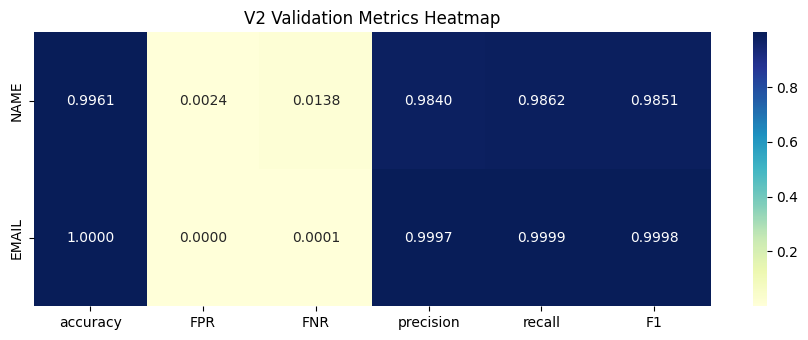

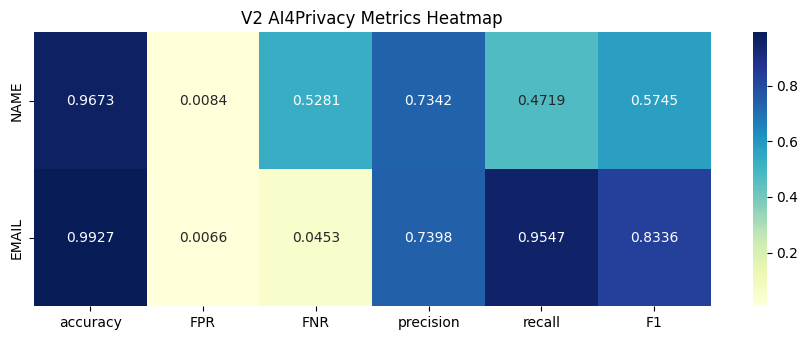

In [ ]:
metric_cols = ['accuracy', 'FPR', 'FNR', 'precision', 'recall', 'F1']

def plot_report_heatmap(report_df, title):
    save_dir = BASE_DIR_OUTPUT / 'reports'
    save_dir.mkdir(parents=True, exist_ok=True)
    
    vals = report_df[metric_cols].copy()
    plt.figure(figsize=(9, 3.5))
    sns.heatmap(vals, annot=True, fmt='.4f', cmap='YlGnBu', cbar=True)
    plt.title(title)
    plt.tight_layout()
    val_heatmap_path = save_dir / 'v2_validation_heatmap.png'
    plt.savefig(val_heatmap_path, dpi=160)
    plt.show()


plot_report_heatmap(v2_report, 'V2 Validation Metrics Heatmap')
plot_report_heatmap(ai4_report, 'V2 AI4Privacy Metrics Heatmap')

label
O        1200
PER      1200
EMAIL    1200
Name: count, dtype: int64


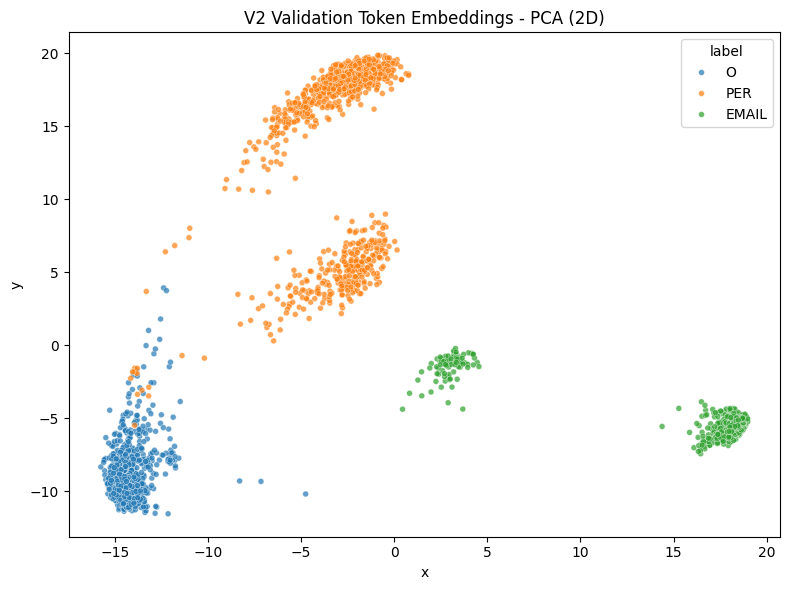

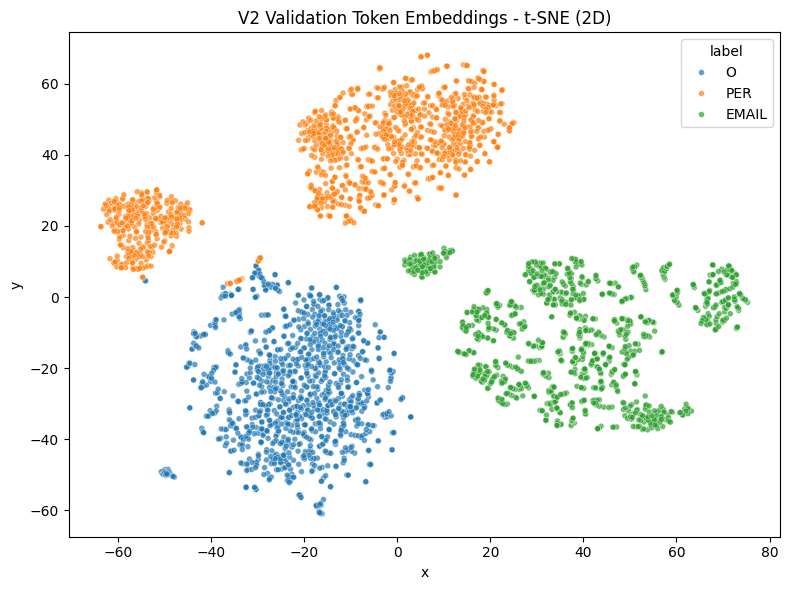


AI4Privacy sample counts:
label
O        1200
PER      1200
EMAIL    1200
Name: count, dtype: int64


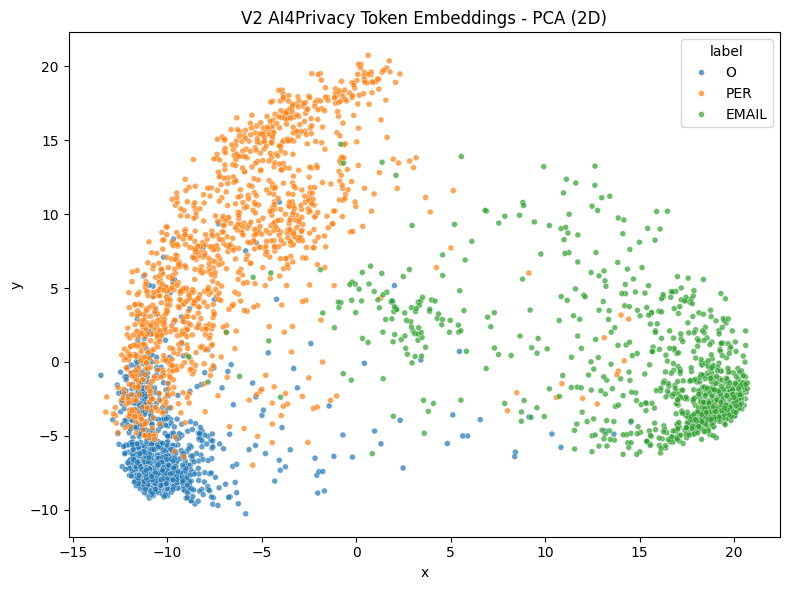

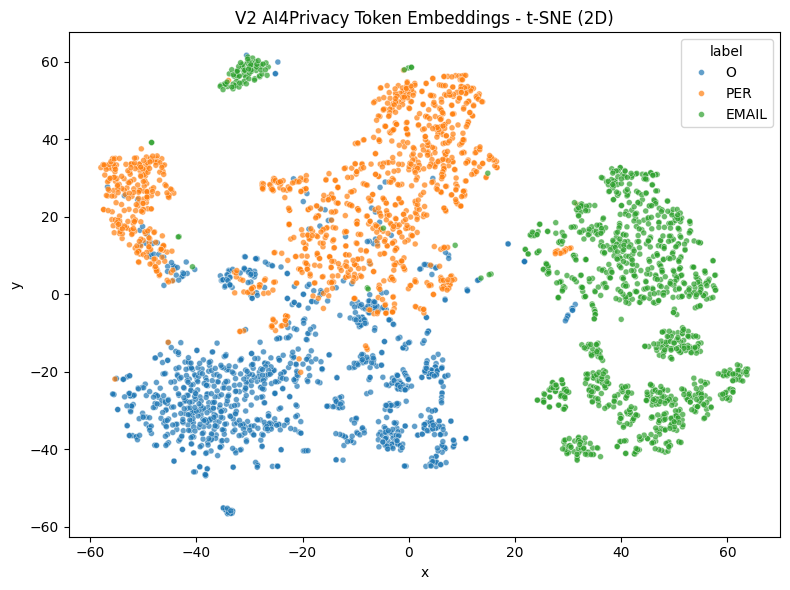

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def build_embedding_projection_df(model_obj, dataset_tok, max_points_per_class=1200, o_sample_ratio=0.35):
    model_obj.eval()

    id_o = label2id['O']
    id_per = {label2id['B-PER'], label2id['I-PER']}
    id_email = {label2id['B-EMAIL'], label2id['I-EMAIL']}

    # Store sampled token embeddings by class for projection plots.
    buckets = {'O': [], 'PER': [], 'EMAIL': []}

    for row in dataset_tok:
        input_ids = torch.tensor([row['input_ids']], device=model_obj.device)
        attention_mask = torch.tensor([row['attention_mask']], device=model_obj.device)
        labels = row['labels']

        with torch.no_grad():
            out = model_obj(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)

        emb = out.hidden_states[-1][0].detach().cpu().numpy()

        for i, label_id in enumerate(labels):
            if label_id == -100:
                continue

            if label_id in id_email:
                cls = 'EMAIL'
            elif label_id in id_per:
                cls = 'PER'
            elif label_id == id_o:
                # Subsample O so it does not dominate the scatter plot.
                if np.random.rand() > o_sample_ratio:
                    continue
                cls = 'O'
            else:
                continue

            if len(buckets[cls]) < max_points_per_class:
                buckets[cls].append(emb[i])

        if all(len(v) >= max_points_per_class for v in buckets.values()):
            break

    rows = []
    for cls, vecs in buckets.items():
        for v in vecs:
            rows.append({'label': cls, 'vec': v})

    return pd.DataFrame(rows)


def plot_embedding_projections(df_embed, title_prefix='Validation'):
    X = np.stack(df_embed['vec'].values)
    y = df_embed['label'].values

    # PCA gives a fast linear projection overview.
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({'x': X_pca[:, 0], 'y': X_pca[:, 1], 'label': y})

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x='x', y='y', hue='label', alpha=0.7, s=18)
    plt.title(f'{title_prefix} Token Embeddings - PCA (2D)')
    plt.tight_layout()
    plt.show()

    # t-SNE captures local nonlinear structure
    n_samples = len(X)
    if n_samples >= 50:
        perplexity = min(30, max(5, n_samples // 20))
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init='pca', learning_rate='auto')
        X_tsne = tsne.fit_transform(X)
        tsne_df = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1], 'label': y})

        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=tsne_df, x='x', y='y', hue='label', alpha=0.7, s=18)
        plt.title(f'{title_prefix} Token Embeddings - t-SNE (2D)')
        plt.tight_layout()
        plt.show()


embed_df = build_embedding_projection_df(model, tok_val, max_points_per_class=1200, o_sample_ratio=0.30)
print(embed_df['label'].value_counts())
plot_embedding_projections(embed_df, title_prefix='V2 Validation')

ai4_embed_df = build_embedding_projection_df(model, ai4_eval_tok, max_points_per_class=1200, o_sample_ratio=0.30)
print('\nAI4Privacy sample counts:')
print(ai4_embed_df['label'].value_counts())
plot_embedding_projections(ai4_embed_df, title_prefix='V2 AI4Privacy')